In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

df = pd.read_csv('data/ending_club_preprocessed2.csv')
data = df.copy()

# 데이터셋 전처리

## 날짜 데이터들의 차이를 수치화하여 파생변수 credit_hist_months 생성

In [49]:
import pandas as pd
import numpy as np

# 1. 공백 제거 및 4자리 연도(%Y) 형식으로 변환
# 사용자님의 데이터가 'Aug-2003' 형식이므로 %b-%Y 를 사용해야 합니다.
data['earliest_cr_line_dt'] = pd.to_datetime(data['earliest_cr_line'].str.strip(), format='%b-%Y', errors='coerce')

# 2. 대출 실행일 변환
data['issue_d_dt'] = pd.to_datetime(data['issue_d'], errors='coerce')

# 3. 개월 수 계산 (정수형으로 변환)
# 두 날짜 중 하나라도 NaN이면 결과도 NaN이 되므로, 변환 성공 여부를 확인하세요.
data['credit_hist_months'] = (
    (data['issue_d_dt'].dt.year - data['earliest_cr_line_dt'].dt.year) * 12 + 
    (data['issue_d_dt'].dt.month - data['earliest_cr_line_dt'].dt.month)
)

# 4. 결과 확인
# print(data[['issue_d', 'earliest_cr_line', 'credit_hist_months']].head())
data['credit_hist_months']

0          148
1          192
2          184
3          210
4          338
          ... 
1277794    147
1277795    175
1277796     64
1277797    230
1277798    207
Name: credit_hist_months, Length: 1277799, dtype: int32

## 변수들 중 target에 영향을 많이 미치는 상위 20개 변수 추출

### 상관관계 확인해서 추출하는 방법

#### 수치형

int_rate                 0.260247
fico_mid                 0.128323
acc_open_past_24mths     0.099707
dti                      0.094544
num_tl_op_past_12m       0.085637
bc_open_to_buy           0.081644
avg_cur_bal              0.078922
tot_hi_cred_lim          0.078470
mort_acc                 0.076117
total_bc_limit           0.072312
tot_cur_bal              0.071203
num_actv_rev_tl          0.070813
num_rev_tl_bal_gt_0      0.069422
inq_last_6mths           0.066653
percent_bc_gt_75         0.065973
loan_amnt                0.064142
bc_util                  0.063347
revol_util               0.058200
mths_since_recent_inq    0.056115
mo_sin_rcnt_tl           0.055177
Name: target, dtype: float64


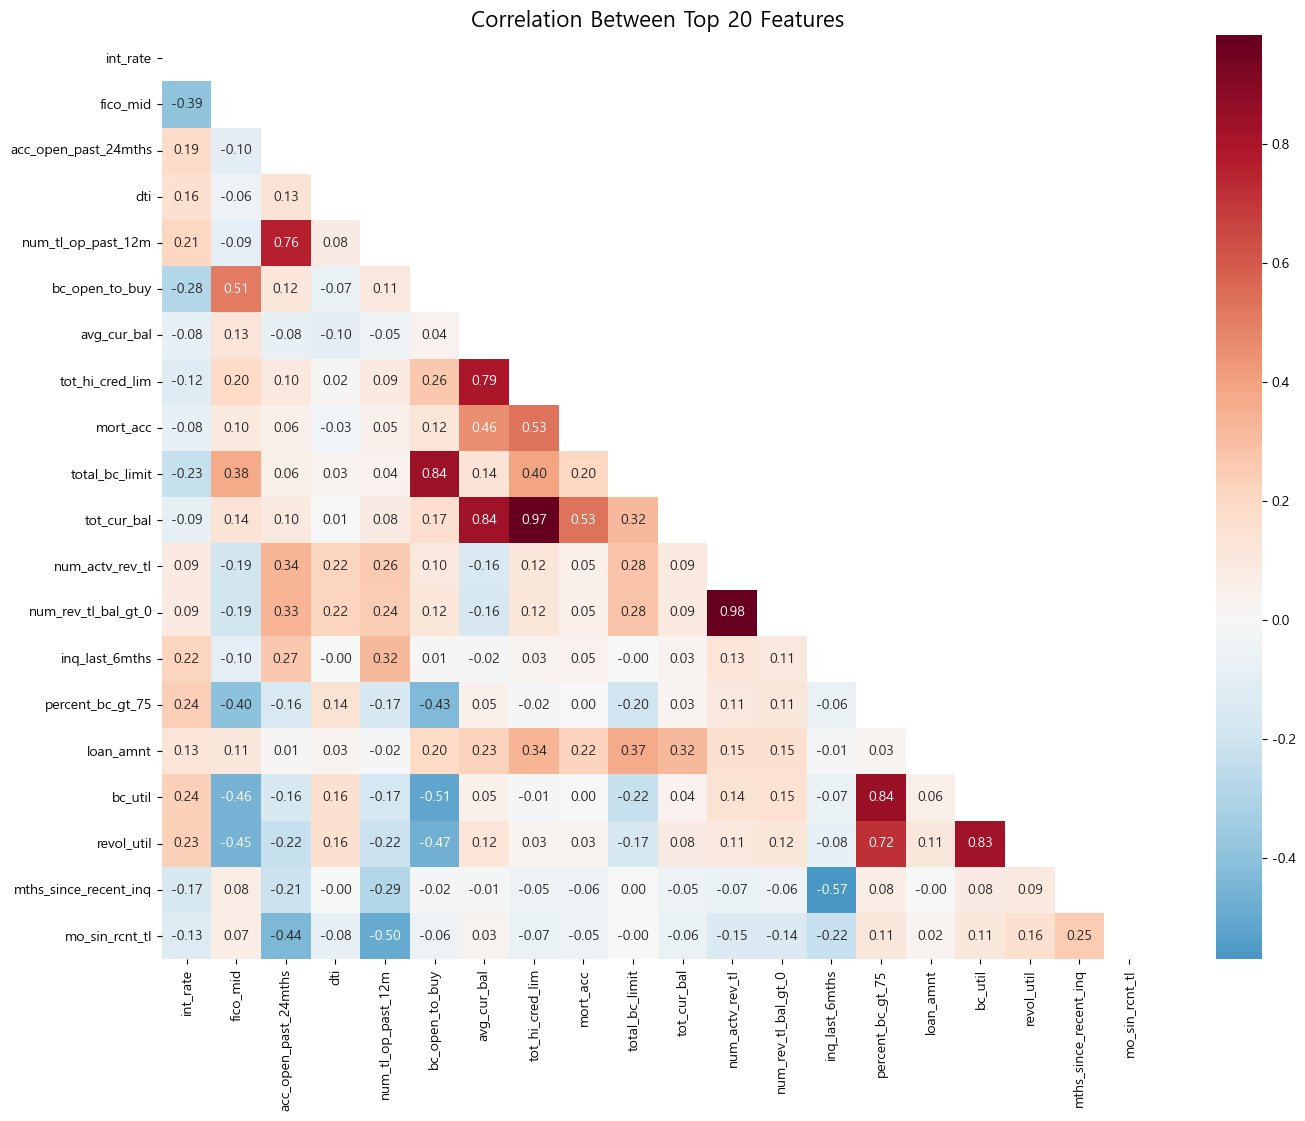

In [50]:
# 1. 수치형 컬럼만 추출 (credit_hist_months도 포함)
num_data = data.select_dtypes(include=[np.number])

# 2. 타겟(target)과의 상관계수 계산
# .corr()은 행렬을 반환하므로 ['target'] 컬럼만 떼어냅니다.
correlations = num_data.corr()['target'].drop('target') 

# 3. 절댓값(abs) 기준 내림차순 정렬하여 상위 20개 선정
# 음의 상관관계(-0.8)도 양의 상관관계(0.8)만큼 중요하기 때문에 절댓값을 씌웁니다.
top_20_filter = correlations.abs().sort_values(ascending=False).head(20)

print(top_20_filter)

# 상위 20개 이름 리스트
top_20_features = top_20_filter.index.tolist() 

# 상위 20개 변수들끼리의 상관관계 행렬 계산(다중공선성 확인)
top_20_corr_matrix = num_data[top_20_features].corr()

# 5. 시각화 (히트맵)
plt.figure(figsize=(16, 12))
# 대칭되는 부분(상삼각형)은 중복이므로 가려줍니다.
mask = np.triu(np.ones_like(top_20_corr_matrix, dtype=bool)) 

sns.heatmap(top_20_corr_matrix, 
            mask=mask, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 2자리
            cmap='RdBu_r',       # 상관관계 색상 (빨강: 양, 파랑: 음)
            center=0)

plt.title('Correlation Between Top 20 Features', fontsize=16)
plt.show()

In [51]:
# 수치형에서 사용할 최종 컬럼들 11개
num_use_cols = [
    'int_rate',             # 이자율 (비용)
    'fico_mid',             # 신용점수 (실력)
    'dti',                  # 부채 비율 (부담)
    'annual_inc',           # 연소득 (상환 능력)
    'acc_open_past_24mths', # 최근 활동 (리스크)
    'mort_acc',             # 주택 담보 (자본력)
    'inq_last_6mths',       # 최근 조회 (급전 여부)
    'credit_hist_months',   # 신용 이력 (내공 - 파생변수)
    'avg_cur_bal',          # 자산 수준 (여유 자금)
    'total_bc_limit',       # 카드 한도 (신용 체급)
    'num_rev_tl_bal_gt_0'   # 부채 계좌 수 (생활 부채)
]

#### 범주형

In [37]:
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency

# 1. 데이터 로드
df = pd.read_csv('data/ending_club_preprocessed2.csv')
data = df.copy()

# 2. 범주형 변수만 선택 (object 타입)
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

# 3. 전처리 (통계 계산을 위해 결측치 처리 및 숫자 변환이 필요합니다)
X_cat = data[cat_cols].copy()
y = data['target']

# 결측치를 최빈값(가장 자주 나오는 값)으로 채웁니다.
imputer = SimpleImputer(strategy='most_frequent')
X_cat_imputed = pd.DataFrame(imputer.fit_transform(X_cat), columns=cat_cols)

# 문자열을 숫자로 변환 (Label Encoding)
# 예: 'MORTGAGE' -> 0, 'RENT' -> 1
for col in cat_cols:
    le = LabelEncoder()
    X_cat_imputed[col] = le.fit_transform(X_cat_imputed[col])

# 4. 통계적 기법 적용

# (1) 카이제곱 테스트 (Chi-squared Test)
# 각 범주형 변수의 '분포'가 타겟에 따라 다른지 봅니다. 점수가 높을수록 연관성이 큽니다.
chi2_scores, p_values = chi2(X_cat_imputed, y)

# (2) 상호 정보량 (Mutual Information)
# 두 변수 간의 정보 의존성을 측정합니다. 0이면 독립, 클수록 연관성이 높습니다.
mi_scores = mutual_info_classif(X_cat_imputed, y, discrete_features=True, random_state=42)

# 5. 결과 정리 및 출력
cat_importance = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2_Score': chi2_scores,
    'P_Value': p_values,
    'Mutual_Info': mi_scores
}).sort_values(by='Mutual_Info', ascending=False) # 상호 정보량 기준으로 정렬

print(cat_importance[['Feature', 'Chi2_Score', 'Mutual_Info']])

C:\Users\gywns\AppData\Local\Temp\ipykernel_11992\2852638451.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object']).columns.tolist()


                                Feature     Chi2_Score   Mutual_Info
2                             sub_grade  359088.920960  3.761544e-02
1                                 grade   84673.667707  3.558542e-02
0                                  term   30581.913950  1.459578e-02
5                   verification_status    6308.572893  4.473872e-03
6                               issue_d   18389.177410  3.588366e-03
4                        home_ownership   10036.900834  2.726193e-03
9                      earliest_cr_line     963.968022  1.768327e-03
7                               purpose    1256.171519  1.486403e-03
8                            addr_state       0.056700  1.371535e-03
3                            emp_length    3424.654721  1.026159e-03
18           mths_since_recent_inq_flag     219.447694  9.422892e-04
17              mths_since_rcnt_il_flag    1320.696099  8.695850e-04
13          mths_since_last_record_flag     906.561466  4.206112e-04
14     mths_since_last_major_derog

In [38]:
# 크래머 V 계산 함수 (범주형 변수용 상관계수)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

# 상위 범주형 변수들 간의 관계 확인
target_cat_cols = ['sub_grade', 'grade', 'term', 'home_ownership', 'purpose', 'addr_state', 'verification_status']
results = []

for col1 in target_cat_cols:
    for col2 in target_cat_cols:
        v = cramers_v(df[col1], df[col2])
        results.append((col1, col2, v))

# 결과 보기
v_matrix = pd.DataFrame(results, columns=['Var1', 'Var2', 'V']).pivot(index='Var1', columns='Var2', values='V')
print(v_matrix)

Var2                 addr_state     grade  home_ownership   purpose  \
Var1                                                                  
addr_state             1.000000  0.017955        0.142483  0.021455   
grade                  0.017955  1.000000        0.051019  0.086876   
home_ownership         0.142483  0.051019        1.000000  0.109567   
purpose                0.021455  0.086876        0.109567  1.000000   
sub_grade              0.009792  1.000000        0.057190  0.061675   
term                   0.041970  0.429128        0.101429  0.096941   
verification_status    0.021427  0.176553        0.028775  0.062076   

Var2                 sub_grade      term  verification_status  
Var1                                                           
addr_state            0.009792  0.041970             0.021427  
grade                 1.000000  0.429128             0.176553  
home_ownership        0.057190  0.101429             0.028775  
purpose               0.061675  0.096941

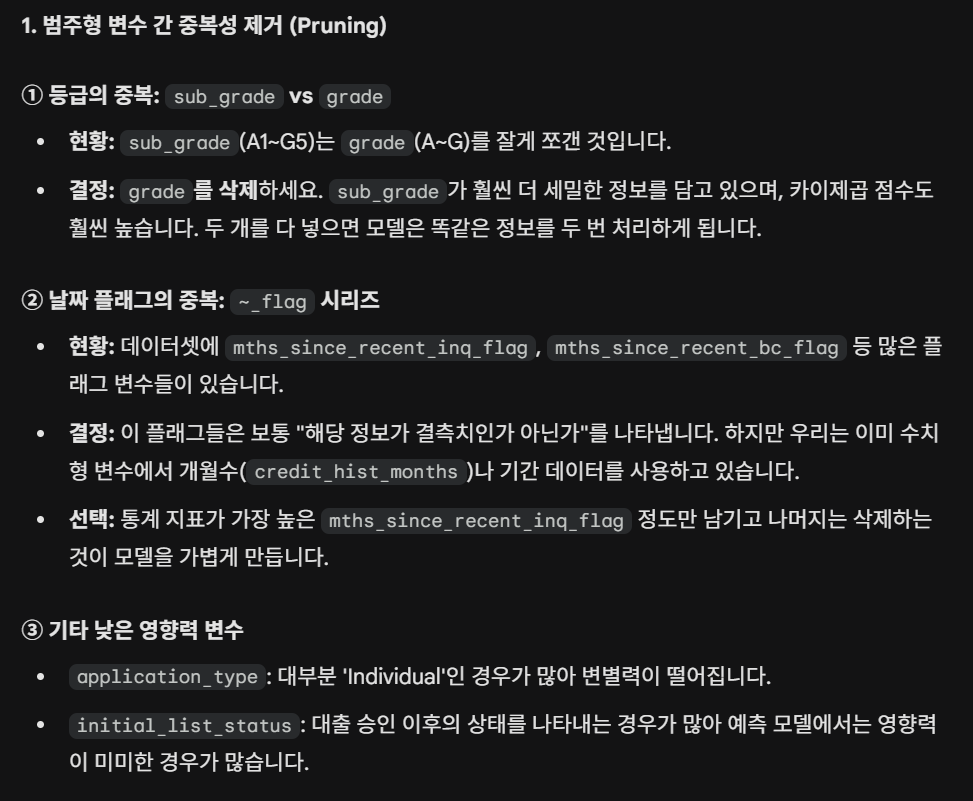

In [40]:
# 범주형에서 사용할 최종 컬럼들 6개
cat_use_cols = [
    'sub_grade',             # 압도적 1위, 신용 등급의 정수
    'term',             # 대출 기간: 36개월 vs 60개월 - 상환 의지에 큰 영향
    'home_ownership',                  # 거주 형태: 자산 상태 대변
    'purpose',           # 대출 목적: 용도에 따른 연체율 차이 존재
    'verification_status', # 소득 증명 여부: 데이터의 신뢰도
    'addr_state'             # 거주 지역: 지역별 경제 상황 반영
]

#### 최종 사용 컬럼

In [42]:
# 최종 컬럼들 17개
use_cols = [
    'int_rate',             # 이자율 (비용)
    'fico_mid',             # 신용점수 (실력)
    'dti',                  # 부채 비율 (부담)
    'annual_inc',           # 연소득 (상환 능력)
    'acc_open_past_24mths', # 최근 활동 (리스크)
    'mort_acc',             # 주택 담보 (자본력)
    'inq_last_6mths',       # 최근 조회 (급전 여부)
    'credit_hist_months',   # 신용 이력 (내공 - 파생변수)
    'avg_cur_bal',          # 자산 수준 (여유 자금)
    'total_bc_limit',       # 카드 한도 (신용 체급)
    'num_rev_tl_bal_gt_0',   # 부채 계좌 수 (생활 부채)
    'sub_grade',             # 압도적 1위, 신용 등급의 정수
    'term',             # 대출 기간: 36개월 vs 60개월 - 상환 의지에 큰 영향
    'home_ownership',                  # 거주 형태: 자산 상태 대변
    'purpose',           # 대출 목적: 용도에 따른 연체율 차이 존재
    'verification_status', # 소득 증명 여부: 데이터의 신뢰도
    'addr_state'             # 거주 지역: 지역별 경제 상황 반영
]


### Feature Importance 확인해서 추출하는 방법

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 로드
df = pd.read_csv('data/ending_club_preprocessed2.csv')

# 2. 전처리 함수 (중요도 산출용)
def get_importance_data(df_in):
    df = df_in.copy()
    
    # [날짜 수치화]
    # 문자열 날짜를 datetime으로 변환
    df['issue_d_dt'] = pd.to_datetime(df['issue_d'], errors='coerce')
    df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'].str.strip(), errors='coerce')
    
    # 2자리 연도 보정 (미래 날짜 방지: 예 2068년 -> 1968년)
    current_year = pd.Timestamp.now().year
    df['earliest_cr_line_dt'] = df['earliest_cr_line_dt'].apply(
        lambda x: x - pd.DateOffset(years=100) if pd.notnull(x) and x.year > current_year else x
    )
    
    # 우리가 앞서 배운 '신용 이력 기간(개월수)' 파생 변수 생성
    df['credit_hist_months'] = (
        (df['issue_d_dt'].dt.year - df['earliest_cr_line_dt'].dt.year) * 12 +
        (df['issue_d_dt'].dt.month - df['earliest_cr_line_dt'].dt.month)
    )
    
    # 원본 날짜 및 계산용 임시 컬럼 제거
    drop_cols = ['issue_d', 'earliest_cr_line', 'issue_d_dt', 'earliest_cr_line_dt']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # [범주형 변수 처리]
    # 모델 학습을 위해 모든 문자열을 숫자로(Label Encoding) 바꿉니다.
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        
    # [결측치 처리]
    # 간단하게 0으로 채워 모델이 돌아가게 합니다.
    df = df.fillna(0)
    
    return df

# 3. 전처리 적용 및 데이터 분리
df_importance = get_importance_data(df)
X = df_importance.drop(columns=['target'])
y = df_importance['target']

# 4. 모델 생성 및 학습 (나무 100그루를 사용하여 변수 중요도 측정)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 5. 모델이 생각하는 중요도 추출 및 상위 20개 출력
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_20_embedded = importances.sort_values(ascending=False).head(20)

print("--- [2번 방법: Embedded] 상위 20개 핵심 피처 ---")
print(top_20_embedded)

C:\Users\gywns\AppData\Local\Temp\ipykernel_11992\1591821326.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'].str.strip(), errors='coerce')
C:\Users\gywns\AppData\Local\Temp\ipykernel_11992\1591821326.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


--- [2번 방법: Embedded] 상위 20개 핵심 피처 ---
int_rate                      0.033821
sub_grade                     0.029885
dti                           0.029121
installment                   0.026242
avg_cur_bal                   0.025156
mo_sin_old_rev_tl_op          0.025122
tot_hi_cred_lim               0.024560
annual_inc                    0.024104
bc_open_to_buy                0.023976
credit_hist_months            0.023926
mo_sin_old_il_acct            0.023900
revol_util                    0.023835
revol_bal                     0.023531
total_rev_hi_lim              0.023500
bc_util                       0.023430
total_bc_limit                0.023426
tot_cur_bal                   0.023374
total_bal_ex_mort             0.022600
loan_amnt                     0.021629
total_il_high_credit_limit    0.020911
dtype: float64


# 로지스틱 회귀

In [53]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. 우리가 선정한 최종 피처 리스트
num_features = [
    'int_rate', 'fico_mid', 'dti', 'annual_inc', 'acc_open_past_24mths', 
    'mort_acc', 'inq_last_6mths', 'credit_hist_months', 'avg_cur_bal', 
    'total_bc_limit', 'num_rev_tl_bal_gt_0'
]
cat_features = [
    'sub_grade', 'term', 'home_ownership', 'purpose', 'verification_status', 'addr_state'
]

X = data[num_features + cat_features]
y = data['target']

# 2. 데이터 분리 (Stratify 적용하여 연체율 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 전처리 파이프라인 (수치형: 중앙값+스케일링 / 범주형: 최빈값+원핫인코딩)
numeric_transformer_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pipe, num_features),
        ('cat', categorical_transformer_pipe, cat_features)
    ])

# 4. [사용자 실습 구조 반영] 로지스틱 회귀 파이프라인
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor), # 전처리 단계 추가
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

# 5. [사용자 실습 구조 반영] GridSearchCV 파라미터 설정
logreg_params = {
    "model__C": [0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logreg_gs = GridSearchCV(
    logreg_pipe,
    param_grid=logreg_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 6. 학습 및 결과 확인
logreg_gs.fit(X_train, y_train)

print("Best Params:", logreg_gs.best_params_)
print("Best CV Score:", logreg_gs.best_score_)

y_pred_log = logreg_gs.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", acc_log)

c:\Users\gywns\OneDrive\바탕 화면\내일배움캠프\2생활관_심화프로젝트\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.8007344660875744
Logistic Regression Accuracy: 0.8010017217091877


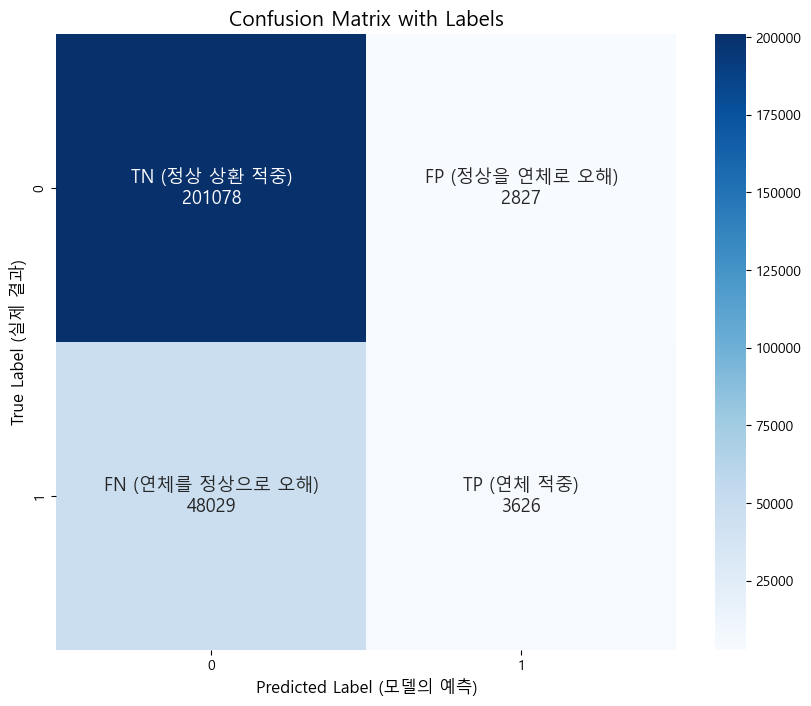


--- 상세 분류 리포트 ---
              precision    recall  f1-score   support

         0.0       0.81      0.99      0.89    203905
         1.0       0.56      0.07      0.12     51655

    accuracy                           0.80    255560
   macro avg       0.68      0.53      0.51    255560
weighted avg       0.76      0.80      0.73    255560



In [55]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. 예측값 얻기
y_pred = logreg_gs.predict(X_test)

# 2. 혼동 행렬 생성
cm = confusion_matrix(y_test, y_pred)

# 3. 각 칸에 들어갈 텍스트 직접 생성 (수치 + 용어)
# 순서: [TN, FP], [FN, TP]
group_names = ['TN (정상 상환 적중)', 'FP (정상을 연체로 오해)', 'FN (연체를 정상으로 오해)', 'TP (연체 적중)']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# 4. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', annot_kws={"size": 13})

plt.title('Confusion Matrix with Labels', fontsize=15)
plt.xlabel('Predicted Label (모델의 예측)', fontsize=12)
plt.ylabel('True Label (실제 결과)', fontsize=12)
plt.show()

# 5. 상세 리포트 (Precision, Recall 등)
print("\n--- 상세 분류 리포트 ---")
print(classification_report(y_test, y_pred))

In [57]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. 우리가 선정한 최종 피처 리스트
num_features = [
    'int_rate', 'fico_mid', 'dti', 'annual_inc', 'acc_open_past_24mths', 
    'mort_acc', 'inq_last_6mths', 'credit_hist_months', 'avg_cur_bal', 
    'total_bc_limit', 'num_rev_tl_bal_gt_0'
]
cat_features = [
    'sub_grade', 'term', 'home_ownership', 'purpose', 'verification_status', 'addr_state'
]

X = data[num_features + cat_features]
y = data['target']

# 2. 데이터 분리 (Stratify 적용하여 연체율 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 전처리 파이프라인 (수치형: 중앙값+스케일링 / 범주형: 최빈값+원핫인코딩)
numeric_transformer_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pipe, num_features),
        ('cat', categorical_transformer_pipe, cat_features)
    ])

# 4. [사용자 실습 구조 반영] 로지스틱 회귀 파이프라인
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000, 
        random_state=42, 
        class_weight='balanced'  # 👈 핵심 옵션 추가!
    ))
])

# 5. [사용자 실습 구조 반영] GridSearchCV 파라미터 설정
logreg_params = {
    "model__C": [0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logreg_gs = GridSearchCV(
    logreg_pipe,
    param_grid=logreg_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

# 6. 학습 및 결과 확인
logreg_gs.fit(X_train, y_train)

y_pred_new = logreg_gs.predict(X_test)
print("--- [1단계] class_weight 추가 후 상세 리포트 ---")
print(classification_report(y_test, y_pred_new))

c:\Users\gywns\OneDrive\바탕 화면\내일배움캠프\2생활관_심화프로젝트\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


--- [1단계] class_weight 추가 후 상세 리포트 ---
              precision    recall  f1-score   support

         0.0       0.89      0.63      0.74    203905
         1.0       0.32      0.68      0.43     51655

    accuracy                           0.64    255560
   macro avg       0.60      0.66      0.59    255560
weighted avg       0.77      0.64      0.68    255560



In [63]:
from sklearn.metrics import precision_recall_curve

# 1. 모델에서 '연체 확률' 가져오기
y_probs = logreg_gs.predict_proba(X_test)[:, 1]

# 2. 임계값 후보군 설정 (0.3~0.5 사이를 0.05 단위로 확인)
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for th in thresholds:
    # 확률이 임계값(th)보다 크면 연체(1)로 분류
    y_pred_th = (y_probs >= th).astype(int)
    
    # 지표 계산
    report = classification_report(y_test, y_pred_th, output_dict=True)
    recall_1 = report['1.0']['recall']
    precision_1 = report['1.0']['precision']
    accuracy = report['accuracy']
    f1_1 = report['1.0']['f1-score']
    
    print(f"Threshold: {th:.2f} | Recall: {recall_1:.4f} | Precision: {precision_1:.4f} | Accuracy: {accuracy:.4f} | F1-Score: {f1_1:.4f}")

Threshold: 0.30 | Recall: 0.9311 | Precision: 0.2427 | Accuracy: 0.3989 | F1-Score: 0.3851
Threshold: 0.35 | Recall: 0.8890 | Precision: 0.2577 | Accuracy: 0.4599 | F1-Score: 0.3995
Threshold: 0.40 | Recall: 0.8339 | Precision: 0.2745 | Accuracy: 0.5208 | F1-Score: 0.4130
Threshold: 0.45 | Recall: 0.7651 | Precision: 0.2945 | Accuracy: 0.5820 | F1-Score: 0.4253
Threshold: 0.50 | Recall: 0.6797 | Precision: 0.3182 | Accuracy: 0.6408 | F1-Score: 0.4334
Threshold: 0.55 | Recall: 0.5781 | Precision: 0.3451 | Accuracy: 0.6930 | F1-Score: 0.4322
Threshold: 0.60 | Recall: 0.4658 | Precision: 0.3783 | Accuracy: 0.7373 | F1-Score: 0.4175
Threshold: 0.65 | Recall: 0.3549 | Precision: 0.4178 | Accuracy: 0.7697 | F1-Score: 0.3838
Threshold: 0.70 | Recall: 0.2474 | Precision: 0.4606 | Accuracy: 0.7893 | F1-Score: 0.3219


ROC-AUC Score: 0.7146
F1-Score (at 0.5): 0.4334


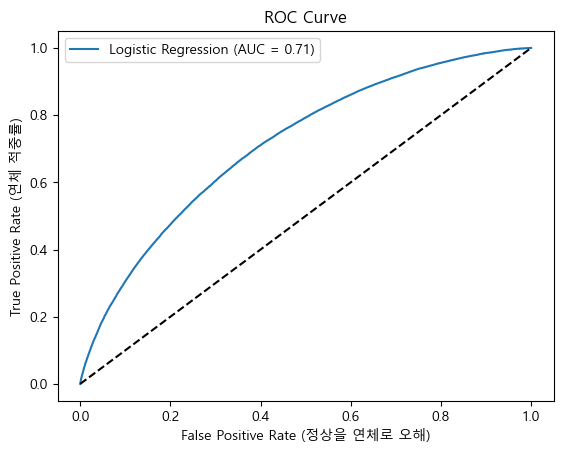

In [64]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

# 1. 확률값과 예측값 가져오기
y_probs = logreg_gs.predict_proba(X_test)[:, 1]
y_pred = logreg_gs.predict(X_test) # 기본 임계값 0.5 기준

# 2. 핵심 지표 계산
auc_score = roc_auc_score(y_test, y_probs)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"F1-Score (at 0.5): {f1:.4f}")

# 3. ROC 커브 시각화 (팀 발표용으로 최고입니다)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # 기준선
plt.xlabel('False Positive Rate (정상을 연체로 오해)')
plt.ylabel('True Positive Rate (연체 적중률)')
plt.title('ROC Curve')
plt.legend()
plt.show()

C:\Users\gywns\AppData\Local\Temp\ipykernel_11992\2485410971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_bottom_coef, palette=colors)


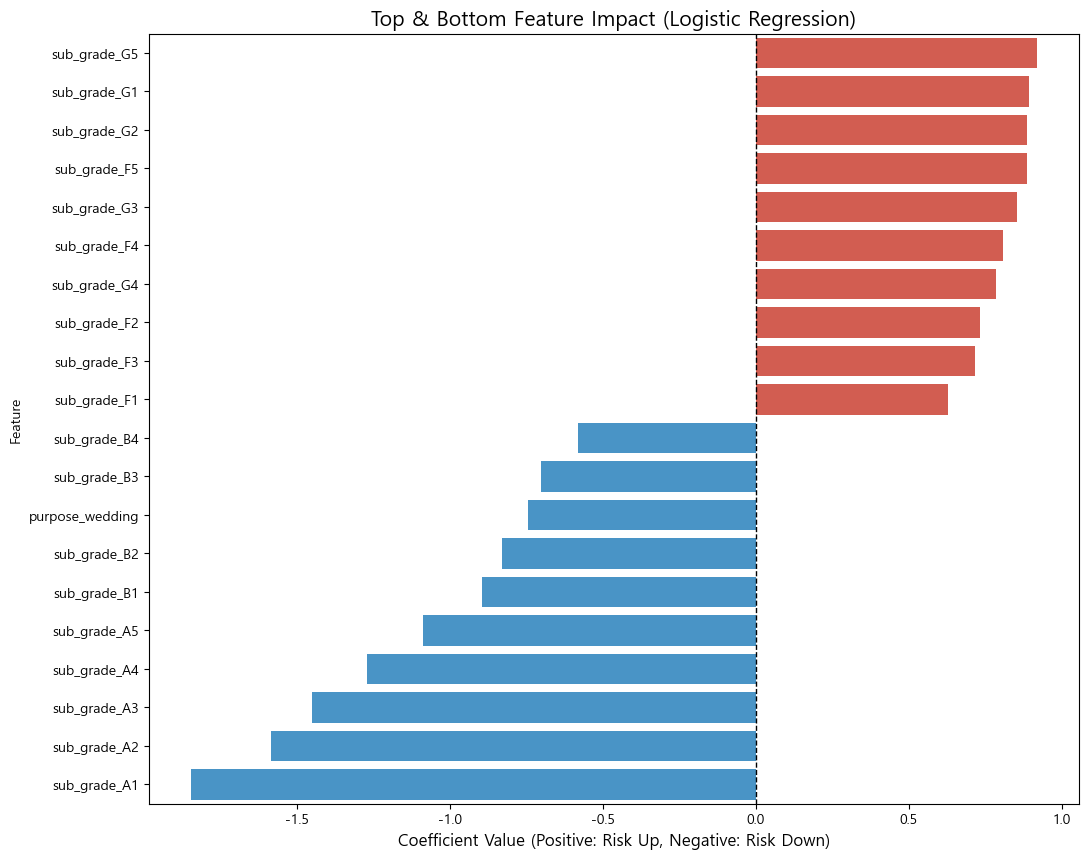

In [65]:
# 1. 최적 모델에서 전처리기와 로지스틱 모델 추출
best_model = logreg_gs.best_estimator_
preprocessor = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

# 2. 인코딩된 전체 피처 이름 가져오기
feature_names = preprocessor.get_feature_names_out()

# 3. 계수(Coefficients) 데이터프레임 생성
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

# 가독성을 위해 이름 정리 (num__, cat__ 제거)
coef_df['Feature'] = coef_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# 4. 영향력 크기순으로 정렬 (절대값 기준이 아닌 실제 값 기준)
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# 5. 시각화 (영향력 Top 10 & Bottom 10)
top_bottom_coef = pd.concat([coef_df.head(10), coef_df.tail(10)])

plt.figure(figsize=(12, 10))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_bottom_coef['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=top_bottom_coef, palette=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Top & Bottom Feature Impact (Logistic Regression)', fontsize=15)
plt.xlabel('Coefficient Value (Positive: Risk Up, Negative: Risk Down)', fontsize=12)
plt.show()

C:\Users\gywns\AppData\Local\Temp\ipykernel_11992\1405006567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=num_coef_df, palette=colors)


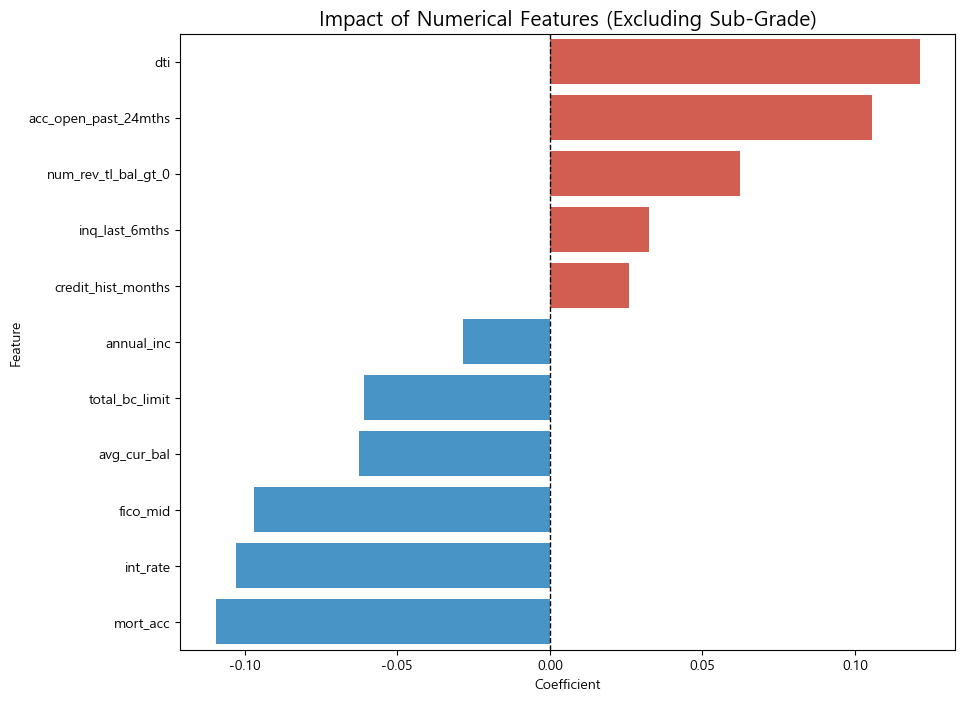

In [66]:
# 수치형 변수(num__)만 필터링해서 다시 시각화
num_coef_df = coef_df[coef_df['Feature'].isin(num_features)].sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in num_coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=num_coef_df, palette=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Impact of Numerical Features (Excluding Sub-Grade)', fontsize=15)
plt.show()

"우리 모델의 판단 근거를 분석한 결과, 예상대로 sub_grade(신용 세부등급)가 연체 예측에 압도적인 영향력을 행사하고 있습니다. 특히 G등급으로 갈수록 연체 위험(Coefficient)이 기하급수적으로 높아지는 것이 확인되었습니다."

"하지만 등급 외의 변수를 살펴보면, 우리가 직접 생성한 credit_hist_months(신용 이력 기간)가 길수록 연체 위험이 낮아지는(Negative Coefficient) 유의미한 경향을 보였습니다. 이는 등급이 낮더라도 신용 이력이 오래된 고객이라면 대출 승인 임계값을 조금 더 유연하게 적용할 근거가 될 수 있습니다."